# POC: Gilda Grounding Threshold Study

Explore how well [Gilda](https://github.com/gyorilab/gilda) grounds the head/tail entities of our **ChemProt** + **EU-ADR** triples to canonical biomedical IDs (HGNC, UniProt, ChEBI, MeSH, etc.).

**Goal** — pick a `score_threshold` and an ungrounded-mention policy for the production normalizers in the rest of the module.

**Sample** — 200 ChemProt triples (with sentence context) and 200 EU-ADR relations (with passage context). Each triple contributes 2 mentions (head, tail), so ~400 grounding calls per dataset.

**Outputs**
1. Hit rate per dataset / role / EU-ADR entity type.
2. Score distribution histograms.
3. Threshold sweep — fraction retained at score >= 0.5, 0.6, ..., 0.9.
4. Worked examples (top, borderline, ungrounded) for inspection.
5. Recommendation block at the end.

In [2]:
import json
import random
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

import gilda  # NOTE: first import is slow (1-2 min) - loads ~2M term resources.

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)
print("gilda version:", gilda.__version__ if hasattr(gilda, "__version__") else "(unknown)")

gilda version: 1.5.0


In [3]:
# --- Configuration --------------------------------------------------------
SEED = 42
N_SAMPLE = 200


def find_project_root(start: Path) -> Path:
    """Walk up from `start` until a directory containing Codes_Solhee_Tucker/ is found."""
    p = start.resolve()
    while p != p.parent:
        if (p / "Codes_Solhee_Tucker").is_dir():
            return p
        p = p.parent
    raise FileNotFoundError(f"Could not find CS225_project root from {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
print("PROJECT_ROOT =", PROJECT_ROOT)

CHEMPROT_PRED_PATH = (
        PROJECT_ROOT
        / "chemprot-relexner-pipeline-main"  # TODO: remove redundant nesting, update code
        / "chemprot-relexner-pipeline-main"
        / "rl_files"
        / "merged_relation_predictions_all_models.json"
)
EUADR_RAW_PATH = PROJECT_ROOT / "298Code_Tran_Brian" / "euadr_full.json"

for p in (CHEMPROT_PRED_PATH, EUADR_RAW_PATH):
    assert p.exists(), f"Missing input file: {p}"

random.seed(SEED)
np.random.seed(SEED)
print("\nInputs OK.")

PROJECT_ROOT = C:\Users\10120\Workspace\CS225_project

Inputs OK.


## 1. Load ChemProt sample

`merged_relation_predictions_all_models.json` is a list of triples; each entry has `sentence`, `head`, `tail`, `relation`, `models`, `confidence`. We sample 200 triples and flatten to 400 mentions (head + tail).

In [4]:
with CHEMPROT_PRED_PATH.open() as f:
    chemprot_all = json.load(f)
print(f"Total ChemProt triples available: {len(chemprot_all):,}")

chemprot_sample = random.sample(chemprot_all, N_SAMPLE)

chemprot_mentions = []
for t in chemprot_sample:
    for role in ("head", "tail"):
        chemprot_mentions.append({
            "dataset": "chemprot",
            "role": role,
            "text": t[role],
            "context": t["sentence"],
            "relation": t.get("relation"),
            "entity_type": None,  # ChemProt JSON does not record per-mention type
        })

print(f"ChemProt mentions to ground: {len(chemprot_mentions)}")
pd.DataFrame(chemprot_mentions).head()

Total ChemProt triples available: 11,796
ChemProt mentions to ground: 400


,dataset,role,text,context,relation,entity_type
0,chemprot,head,OATP8,"In complementary RNA (cRNA)-injected Xenopus laevis oocytes, rifamycin SV (1...",CPR:4,None
1,chemprot,tail,BSP,"In complementary RNA (cRNA)-injected Xenopus laevis oocytes, rifamycin SV (1...",CPR:4,None
2,chemprot,head,ICI,"ICI 182,780 (fulvestrant) (Faslodex) and ICI 164,384 are competitive inhibit...",CPR:3,None
3,chemprot,tail,"ICI 182,780","ICI 182,780 (fulvestrant) (Faslodex) and ICI 164,384 are competitive inhibit...",CPR:3,None
4,chemprot,head,h5-HT(1A,"Yohimbine displays marked affinity at human (h)alpha(2A)-, halpha(2B)- and h...",CPR:6,None


## 2. Load EU-ADR sample

`euadr_full.json` is the raw BigBio `euadr_bigbio_kb` dataset - one record per document, with `passages`, `entities`, and `relations`. We pull all `(arg1, arg2)` pairs that point to known entities, attach the joined passage text as context, then sample `N_SAMPLE` relations to match the ChemProt sample size.

In [5]:
with EUADR_RAW_PATH.open() as f:
    euadr_raw = json.load(f)
print(f"EU-ADR documents: {len(euadr_raw)}")


def passage_text(doc):
    """Concatenate all passage strings for a doc into a single context blob."""
    parts = []
    for p in doc["passages"]:
        txt = p["text"]
        parts.extend(txt if isinstance(txt, list) else [txt])
    return " ".join(parts)


euadr_pairs = []  # one per relation
for doc in euadr_raw:
    if not doc.get("relations"):
        continue
    ctx = passage_text(doc)
    ent_map = {e["id"]: e for e in doc["entities"]}
    for rel in doc["relations"]:
        head_e = ent_map.get(rel["arg1_id"])
        tail_e = ent_map.get(rel["arg2_id"])
        if not head_e or not tail_e:
            continue
        euadr_pairs.append((rel, head_e, tail_e, ctx))

print(f"EU-ADR usable relations: {len(euadr_pairs)}")

rel_sample = random.sample(euadr_pairs, min(N_SAMPLE, len(euadr_pairs)))


def ent_text(e):
    t = e["text"]
    return (t[0] if isinstance(t, list) else t).strip()


euadr_mentions = []
for rel, head_e, tail_e, ctx in rel_sample:
    for ent, role in [(head_e, "head"), (tail_e, "tail")]:
        text = ent_text(ent)
        if not text:
            continue
        euadr_mentions.append({
            "dataset": "euadr",
            "role": role,
            "text": text,
            "context": ctx,
            "relation": rel.get("type"),
            "entity_type": ent.get("type") or "Unknown",
        })

print(f"EU-ADR mentions to ground: {len(euadr_mentions)}")
pd.DataFrame(euadr_mentions).head()

EU-ADR documents: 300
EU-ADR usable relations: 2891
EU-ADR mentions to ground: 400


,dataset,role,text,context,relation,entity_type
0,euadr,head,Garcinia kola nut extract,Pupillary changes among Nigerian adults following the instillation of Garcin...,PA,Unknown
1,euadr,tail,miosis,Pupillary changes among Nigerian adults following the instillation of Garcin...,PA,Unknown
2,euadr,head,XRCC4,RAD52 polymorphisms contribute to the development of papillary thyroid cance...,PA,Unknown
3,euadr,tail,DNA damage,RAD52 polymorphisms contribute to the development of papillary thyroid cance...,PA,Unknown
4,euadr,head,TGFBIp/betaig-h3,TGFBIp/betaig-h3 protein: a versatile matrix molecule induced by TGF-beta. T...,SA,Unknown


## 3. Run Gilda grounding

`gilda.ground(text, context=...)` returns a list of `ScoredMatch` ordered by score. We keep the top match's `(db, id, name, score)`, plus a `matched` flag and the candidate count.

The first call is slow (resource load); subsequent calls are fast (a few ms each).

In [6]:
def ground_one(text: str, context: Optional[str] = None) -> dict:
    """Return the top Gilda match for a surface form, or empty fields if none."""
    try:
        matches = gilda.ground(text, context=context)
    except Exception as e:
        return {"db": None, "id": None, "name": None, "score": 0.0,
                "matched": False, "n_candidates": 0, "error": str(e)}
    if not matches:
        return {"db": None, "id": None, "name": None, "score": 0.0,
                "matched": False, "n_candidates": 0, "error": None}
    top = matches[0]
    return {
        "db": top.term.db,
        "id": top.term.id,
        "name": top.term.entry_name,
        "score": float(top.score),
        "matched": True,
        "n_candidates": len(matches),
        "error": None,
    }


# Warm-up call (forces resource loading; subsequent calls are fast).
warmup = ground_one("TP53")
print("Warm-up grounding for 'TP53':", warmup)

Warm-up grounding for 'TP53': {'db': 'HGNC', 'id': '11998', 'name': 'TP53', 'score': 1.0, 'matched': True, 'n_candidates': 1, 'error': None}


In [7]:
rows = []
for m in tqdm(chemprot_mentions, desc="Grounding ChemProt"):
    g = ground_one(m["text"], context=m["context"])
    rows.append({**m, **g})
df_chemprot = pd.DataFrame(rows)
df_chemprot.head()

Grounding ChemProt:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: [2026-05-09 14:39:24] gilda.grounder - Running Gilda disambiguation for AE2


,dataset,role,text,context,relation,entity_type,db,id,name,score,matched,n_candidates,error
0,chemprot,head,OATP8,"In complementary RNA (cRNA)-injected Xenopus laevis oocytes, rifamycin SV (1...",CPR:4,None,HGNC,10961,SLCO1B3,0.555556,True,1,None
1,chemprot,tail,BSP,"In complementary RNA (cRNA)-injected Xenopus laevis oocytes, rifamycin SV (1...",CPR:4,None,HGNC,5341,IBSP,0.555556,True,1,None
2,chemprot,head,ICI,"ICI 182,780 (fulvestrant) (Faslodex) and ICI 164,384 are competitive inhibit...",CPR:3,None,None,None,None,0.000000,False,0,None
3,chemprot,tail,"ICI 182,780","ICI 182,780 (fulvestrant) (Faslodex) and ICI 164,384 are competitive inhibit...",CPR:3,None,None,None,None,0.000000,False,0,None
4,chemprot,head,h5-HT(1A,"Yohimbine displays marked affinity at human (h)alpha(2A)-, halpha(2B)- and h...",CPR:6,None,None,None,None,0.000000,False,0,None


In [8]:
rows = []
for m in tqdm(euadr_mentions, desc="Grounding EU-ADR"):
    g = ground_one(m["text"], context=m["context"])
    rows.append({**m, **g})
df_euadr = pd.DataFrame(rows)
df_euadr

Grounding EU-ADR:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: [2026-05-09 14:39:25] gilda.grounder - Running Gilda disambiguation for LCA
INFO: [2026-05-09 14:39:25] gilda.grounder - Running Gilda disambiguation for BMD
INFO: [2026-05-09 14:39:25] gilda.grounder - Running Gilda disambiguation for MRP1
INFO: [2026-05-09 14:39:25] gilda.grounder - Running Gilda disambiguation for LCA


,dataset,role,text,context,relation,entity_type,db,id,name,score,matched,n_candidates,error
0,euadr,head,Garcinia kola nut extract,Pupillary changes among Nigerian adults following the instillation of Garcin...,PA,Unknown,None,None,None,0.000000,False,0,None
1,euadr,tail,miosis,Pupillary changes among Nigerian adults following the instillation of Garcin...,PA,Unknown,MESH,D015877,Miosis,0.762317,True,1,None
2,euadr,head,XRCC4,RAD52 polymorphisms contribute to the development of papillary thyroid cance...,PA,Unknown,HGNC,12831,XRCC4,0.777778,True,1,None
3,euadr,tail,DNA damage,RAD52 polymorphisms contribute to the development of papillary thyroid cance...,PA,Unknown,MESH,D004249,DNA Damage,0.771593,True,1,None
4,euadr,head,TGFBIp/betaig-h3,TGFBIp/betaig-h3 protein: a versatile matrix molecule induced by TGF-beta. T...,SA,Unknown,None,None,None,0.000000,False,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,euadr,tail,anterior shoulder dislocation,Intra-articular lidocaine versus intravenous meperidine/diazepam in anterior...,PA,Unknown,None,None,None,0.000000,False,0,None
396,euadr,head,CEP290-LCA patients,Hypomorphic CEP290/NPHP6 mutations result in anosmia caused by the selective...,PA,Unknown,None,None,None,0.000000,False,0,None
397,euadr,tail,LCA,Hypomorphic CEP290/NPHP6 mutations result in anosmia caused by the selective...,PA,Unknown,HGNC,4689,GUCY2D,0.251063,True,4,None
398,euadr,head,MDR1,Effects of polymorphism in G2677T/A triallelic region of MDR1 gene in Turkis...,NA,Unknown,HGNC,21710,TBC1D9,0.555556,True,2,None


In [9]:
df = pd.concat([df_chemprot, df_euadr], ignore_index=True)
print("Combined shape:", df.shape)
df.head()

Combined shape: (800, 13)


,dataset,role,text,context,relation,entity_type,db,id,name,score,matched,n_candidates,error
0,chemprot,head,OATP8,"In complementary RNA (cRNA)-injected Xenopus laevis oocytes, rifamycin SV (1...",CPR:4,None,HGNC,10961,SLCO1B3,0.555556,True,1,None
1,chemprot,tail,BSP,"In complementary RNA (cRNA)-injected Xenopus laevis oocytes, rifamycin SV (1...",CPR:4,None,HGNC,5341,IBSP,0.555556,True,1,None
2,chemprot,head,ICI,"ICI 182,780 (fulvestrant) (Faslodex) and ICI 164,384 are competitive inhibit...",CPR:3,None,None,None,None,0.000000,False,0,None
3,chemprot,tail,"ICI 182,780","ICI 182,780 (fulvestrant) (Faslodex) and ICI 164,384 are competitive inhibit...",CPR:3,None,None,None,None,0.000000,False,0,None
4,chemprot,head,h5-HT(1A,"Yohimbine displays marked affinity at human (h)alpha(2A)-, halpha(2B)- and h...",CPR:6,None,None,None,None,0.000000,False,0,None


## 4. Hit rate

In [10]:
def summarize(label, frame):
    total = len(frame)
    matched = int(frame["matched"].sum())
    med = frame.loc[frame["matched"], "score"].median() if matched else None
    return {
        "group": label,
        "n": total,
        "matched": matched,
        "hit_rate": round(matched / total, 3) if total else 0.0,
        "median_matched_score": round(med, 3) if med is not None else None,
    }


summary = pd.DataFrame([

    summarize("chemprot.head", df[(df.dataset == "chemprot") & (df.role == "head")]),
    summarize("chemprot.tail", df[(df.dataset == "chemprot") & (df.role == "tail")]),
    summarize("euadr.head", df[(df.dataset == "euadr") & (df.role == "head")]),
    summarize("euadr.tail", df[(df.dataset == "euadr") & (df.role == "tail")]),
    summarize("OVERALL", df),
])
summary

,group,n,matched,hit_rate,median_matched_score
0,chemprot.head,200,126,0.630,0.778
1,chemprot.tail,200,122,0.610,0.778
2,euadr.head,200,115,0.575,0.778
3,euadr.tail,200,138,0.690,0.778
4,OVERALL,800,501,0.626,0.778


In [11]:
# EU-ADR has labelled entity types - worth seeing per-type hit rate.
eu = df[df.dataset == "euadr"]
by_type = (
    eu.groupby("entity_type")
    .agg(n=("matched", "size"), hit_rate=("matched", "mean"))
    .round(3)
    .sort_values("n", ascending=False)
    .reset_index()
)
print("EU-ADR hit rate by entity type:")
by_type

EU-ADR hit rate by entity type:


,entity_type,n,hit_rate
0,Unknown,400,0.632


In [12]:
# Which namespaces (HGNC, CHEBI, MESH, ...) does Gilda actually pick?
matched_only = df[df["matched"]]
ns_counts = (
    matched_only.groupby(["dataset", "db"]).size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
print("Top-match namespace counts per dataset:")
ns_counts

Top-match namespace counts per dataset:


db,CHEBI,DOID,EFO,FPLX,GO,HGNC,MESH
dataset,,,,,,,
chemprot,130,0,0,11,3,74,30
euadr,71,10,6,10,7,75,74


## 5. Score distribution

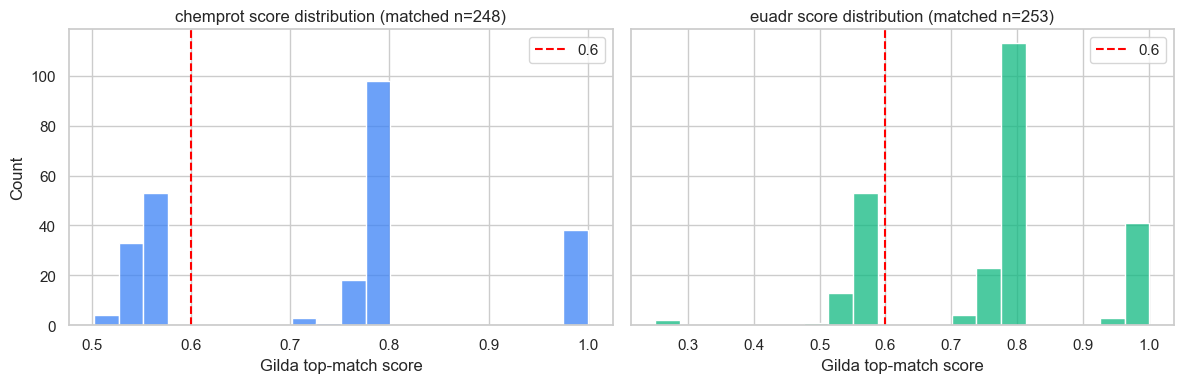

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
matched = df[df["matched"]]
for ax, ds, color in zip(axes, ["chemprot", "euadr"], ["#3b82f6", "#10b981"]):
    sub = matched[matched.dataset == ds]
    sns.histplot(sub["score"], bins=20, ax=ax, color=color)
    ax.axvline(0.6, color="red", linestyle="--", label="0.6")
    ax.set_title(f"{ds} score distribution (matched n={len(sub)})")
    ax.set_xlabel("Gilda top-match score")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Threshold sweep

How many mentions survive at each threshold? This is the main input for the threshold decision.

In [14]:
thresholds = [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
rows = []
for thr in thresholds:
    for ds in ("chemprot", "euadr"):
        sub = df[df.dataset == ds]
        kept = int((sub["matched"] & (sub["score"] >= thr)).sum())
        rows.append({
            "dataset": ds,
            "threshold": thr,
            "kept": kept,
            "kept_pct": round(kept / len(sub), 3) if len(sub) else 0.0,
        })
sweep_df = pd.DataFrame(rows)
pivot = sweep_df.pivot(index="threshold", columns="dataset", values="kept_pct")
print("Fraction of mentions retained at each threshold:")
pivot

Fraction of mentions retained at each threshold:


dataset,chemprot,euadr
threshold,,
0.50,0.620,0.625
0.60,0.395,0.460
0.65,0.395,0.460
0.70,0.395,0.460
0.75,0.385,0.450
0.80,0.095,0.110
0.85,0.095,0.110
0.90,0.095,0.110


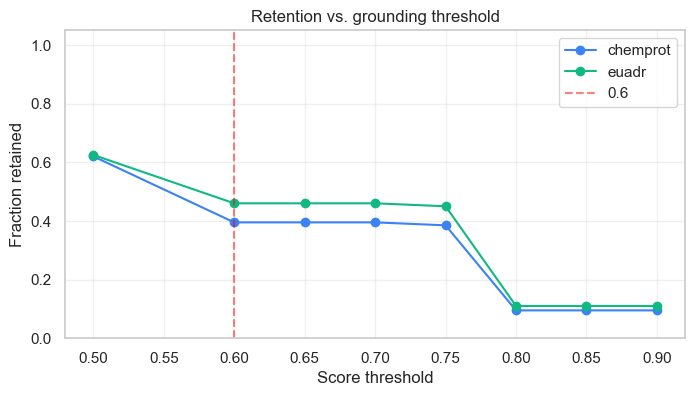

In [15]:
plt.figure(figsize=(8, 4))
for ds, color in [("chemprot", "#3b82f6"), ("euadr", "#10b981")]:
    s = sweep_df[sweep_df.dataset == ds]
    plt.plot(s["threshold"], s["kept_pct"], marker="o", label=ds, color=color)
plt.axvline(0.6, color="red", linestyle="--", alpha=0.5, label="0.6")
plt.xlabel("Score threshold")
plt.ylabel("Fraction retained")
plt.title("Retention vs. grounding threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Worked examples

Sanity-check the matches by eye - especially the borderline 0.5-0.7 band, where threshold choice matters most.

In [16]:
cols = ["dataset", "role", "text", "db", "id", "name", "score", "entity_type"]
print("=== Top-10 high-confidence matches ===")
display(df[df["matched"]].nlargest(10, "score")[cols])

=== Top-10 high-confidence matches ===


,dataset,role,text,db,id,name,score,entity_type
39,chemprot,tail,insulin,HGNC,6081,INS,1.0,None
50,chemprot,head,PDE5,HGNC,8784,PDE5A,1.0,None
51,chemprot,tail,PDE5,HGNC,8784,PDE5A,1.0,None
52,chemprot,head,Raf-1,HGNC,9829,RAF1,1.0,None
53,chemprot,tail,Lck,HGNC,6524,LCK,1.0,None
65,chemprot,tail,cytosolic phospholipase A2,FPLX,PLA2,PLA2,1.0,None
91,chemprot,tail,oxygen,CHEBI,CHEBI:15379,dioxygen,1.0,None
92,chemprot,head,calcium,CHEBI,CHEBI:29108,calcium(2+),1.0,None
113,chemprot,tail,JNK,FPLX,JNK,JNK,1.0,None
134,chemprot,head,IKK,FPLX,IKK_complex,IKK_complex,1.0,None


In [17]:
print("=== Borderline matches (0.5 <= score < 0.7) ===")
border = df[df["matched"] & df["score"].between(0.5, 0.7, inclusive="left")]
display(border[cols].sort_values("score").head(20))

=== Borderline matches (0.5 <= score < 0.7) ===


,dataset,role,text,db,id,name,score,entity_type
25,chemprot,tail,TxB2,CHEBI,CHEBI:28728,thromboxane B2,0.502371,None
100,chemprot,head,Hsp72,HGNC,5232,HSPA1A,0.502371,None
283,chemprot,tail,TxB2,CHEBI,CHEBI:28728,thromboxane B2,0.502371,None
6,chemprot,head,mAch,HGNC,1509,CASP8,0.520924,None
520,euadr,head,MD,CHEBI,CHEBI:33395,mendelevium atom,0.539476,Unknown
376,chemprot,head,SB,CHEBI,CHEBI:30513,antimony atom,0.539476,None
296,chemprot,head,SB,CHEBI,CHEBI:30513,antimony atom,0.539476,None
632,euadr,head,MD,CHEBI,CHEBI:33395,mendelevium atom,0.539476,Unknown
76,chemprot,head,prostacyclin,CHEBI,CHEBI:15552,prostaglandin I2,0.540095,None
208,chemprot,head,rat,MESH,D051381,Rats,0.540095,None


In [18]:
print("=== Ungrounded mentions (no Gilda match at all) ===")
display(df[~df["matched"]][["dataset", "role", "text", "entity_type"]].head(20))
ungrounded_pct = (~df['matched']).mean()
print(f"\nTotal ungrounded: {(~df['matched']).sum()} / {len(df)} ({ungrounded_pct:.1%})")

=== Ungrounded mentions (no Gilda match at all) ===


,dataset,role,text,entity_type
2,chemprot,head,ICI,None
3,chemprot,tail,"ICI 182,780",None
4,chemprot,head,h5-HT(1A,None
5,chemprot,tail,hD(3) receptors,None
7,chemprot,tail,mAch receptor,None
8,chemprot,head,Ca2+ channel,None
12,chemprot,head,mammalian,None
19,chemprot,tail,extracellular signal regulated kinase (ERK)-2,None
23,chemprot,tail,PHA1,None
26,chemprot,head,alpha(2)-AR,None



Total ungrounded: 299 / 800 (37.4%)


## 8. Recommendation

Fill in after running the cells above:

**Decisions for `Codes_Solhee_Tucker/config.py`:**

1. **`SCORE_THRESHOLD = ?`** - pick from the sweep above. Aim for the lowest value where the borderline-band examples (cell 7.2) are still clearly correct. Common choices: 0.7 (Gilda's recommended default), or 0.6 if recall matters more than precision for your KG.
2. **Ungrounded policy** - `drop` (skip the triple) vs. `keep_as_raw` (use the surface form as the node id). Look at cell 7.3: are the ungrounded entities mostly noise (good -> drop) or real entities Gilda just doesn't cover (good -> keep)?
3. **Per-namespace caveats** - from the namespace-mix and per-type hit-rate tables. If `Diseases & Disorders` or `SNP & Sequence variations` show low hit rate, document this as a known limitation in the rebuttal and consider a fallback (e.g., MeSH lookup for diseases).

Once decided, encode the choices in `config.py` and proceed to `normalize_chemprot.py` / `normalize_euadr.py`.

In [19]:
# Optional: persist the per-mention POC results so we can reference them later
# without re-running grounding.
OUT_PATH = Path("poc_results.csv")
df.to_csv(OUT_PATH, index=False)
print(f"Saved POC results to: {OUT_PATH.resolve()}")

Saved POC results to: C:\Users\10120\Workspace\CS225_project\Codes_Solhee_Tucker\poc\poc_results.csv
